In [19]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

Path('../figs/clustering').mkdir(parents=True, exist_ok=True)

con = duckdb.connect('../data/capstone.duckdb')

df = con.execute("""
    SELECT *
    FROM gold.mrt_customer_features
    WHERE Individual = 'Y'
""").fetchdf()

con.close()

print(f'Loaded: {len(df):,} individual customers')
print(f'Columns: {df.shape[1]}')

Loaded: 58,840 individual customers
Columns: 57


## Null Check

In [20]:
# Check nulls before imputation
print("Null counts before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal rows: {len(df):,}")

Null counts before imputation:
std_transaction_amount           2567
dec_to_nov_daily_spend_ratio    11196
jan_to_dec_daily_spend_ratio     7037
RelationshipYears                   9
dec_to_nov_avg_amount_ratio     11196
jan_to_dec_avg_amount_ratio      7037
dtype: int64

Total rows: 58,840


## Impute

In [21]:
# Impute nulls
df['std_transaction_amount'] = df['std_transaction_amount'].fillna(0)

ratio_cols = [
    'dec_to_nov_daily_spend_ratio',
    'jan_to_dec_daily_spend_ratio',
    'dec_to_nov_avg_amount_ratio',
    'jan_to_dec_avg_amount_ratio'
]
df[ratio_cols] = df[ratio_cols].fillna(1.0)
df['RelationshipYears'] = df['RelationshipYears'].fillna(df['RelationshipYears'].median())

# Verify
remaining_nulls = df.isnull().sum()[df.isnull().sum() > 0]
if len(remaining_nulls) == 0:
    print('No nulls remaining.')
else:
    print(remaining_nulls)

No nulls remaining.


## Removing certain outliers

In [22]:
suspicious_ids = df[
    (df['transaction_count'] <= 10) &
    (df['avg_transaction_amount'] > 1000)
]['customer_id']

df_model = df[~df['customer_id'].isin(suspicious_ids)].copy()

print(f'Original:  {len(df):,} customers')
print(f'Removed:   {len(suspicious_ids):,} one-off large payment customers')
print(f'Remaining: {len(df_model):,} customers')

Original:  58,840 customers
Removed:   163 one-off large payment customers
Remaining: 58,677 customers


## Transforming skewed features

K-Means uses Euclidean distance. Features with extreme right skew -- where
a few customers have values 100x higher than the median -- dominate distance
calculations and distort clustering.

Two transformations applied:

**Log transform** on 8 amount and count columns (skewness > 2).
Compresses extreme values while preserving relative ordering.
Uses log1p (log(1+x)) to safely handle zero values.

**Percentile capping** on 4 ratio columns (skewness > 100).
Clips values to the 5th-95th percentile range. Ratios above p95
represent noise (e.g. spending $0.50 in Nov and $500 in Dec = ratio of 1000)
rather than meaningful signal.

Category share columns are NOT transformed -- their zeros are meaningful
(a customer who never spends on pets is genuinely different from one who does).

In [23]:
# Log transform amount and count columns
log_cols = [
    'total_spend',
    'avg_transaction_amount',
    'max_transaction_amount',
    'median_transaction_amount',
    'min_transaction_amount',
    'std_transaction_amount',
    'transaction_count',
    'unique_merchants'
]

for col in log_cols:
    df_model[f'{col}_log'] = np.log1p(df_model[col])
    df_model = df_model.drop(columns=[col])

# Cap ratio columns at 5th and 95th percentile
for col in ratio_cols:
    p5  = df_model[col].quantile(0.05)
    p95 = df_model[col].quantile(0.95)
    df_model[col] = df_model[col].clip(lower=p5, upper=p95)

# Final feature list
identifier_cols   = ['customer_id', 'Individual']
feature_cols_final = [col for col in df_model.columns
                      if col not in identifier_cols]

print(f'Total features: {len(feature_cols_final)}')
print(f'Total customers: {len(df_model):,}')

Total features: 55
Total customers: 58,677


## Scaling features

In [24]:
X = df_model[feature_cols_final].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix: {X_scaled.shape}')

Feature matrix: (58677, 55)


## Experimenting cluster number with K-Means

  k=2  inertia=   2,987,569  silhouette=0.1784
  k=3  inertia=   2,892,595  silhouette=0.1091
  k=4  inertia=   2,782,380  silhouette=0.1096
  k=5  inertia=   2,744,765  silhouette=0.0620
  k=6  inertia=   2,655,881  silhouette=0.0241
  k=7  inertia=   2,594,446  silhouette=0.0717
  k=8  inertia=   2,537,184  silhouette=0.0700
  k=9  inertia=   2,494,946  silhouette=0.0679
  k=10  inertia=   2,437,464  silhouette=0.0744


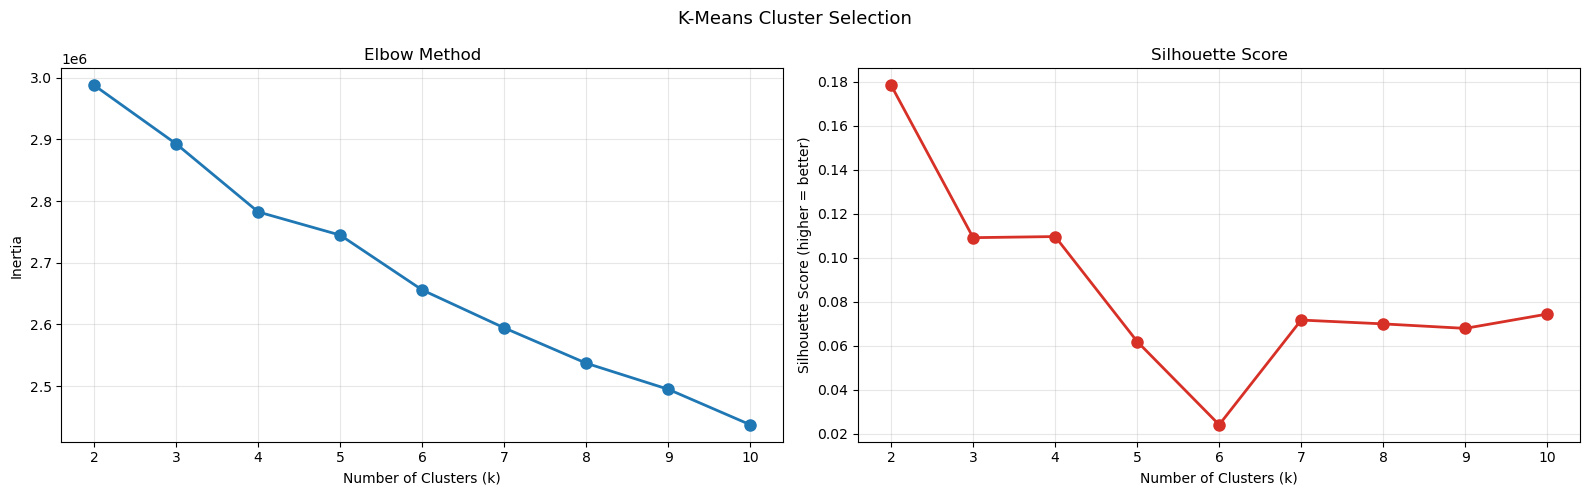

In [25]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)
    print(f'  k={k}  inertia={kmeans.inertia_:>12,.0f}  silhouette={score:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_range, inertia, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2,
             markersize=8, color='#d73027')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_xticks(k_range)
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Cluster Selection', fontsize=13)
plt.tight_layout()
fig.savefig('../figs/clustering/cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()


## Experimenting cluster number with GMMs

  k=2  BIC=     2,759,197  AIC=     2,730,542
  k=3  BIC=       655,228  AIC=       612,241
  k=4  BIC=      -252,566  AIC=      -309,884
  k=5  BIC=    -1,682,361  AIC=    -1,754,010
  k=6  BIC=    -1,898,640  AIC=    -1,984,622
  k=7  BIC=    -2,858,363  AIC=    -2,958,676
  k=8  BIC=    -3,237,593  AIC=    -3,352,239
  k=9  BIC=    -3,169,285  AIC=    -3,298,262
  k=10  BIC=    -3,666,667  AIC=    -3,809,976


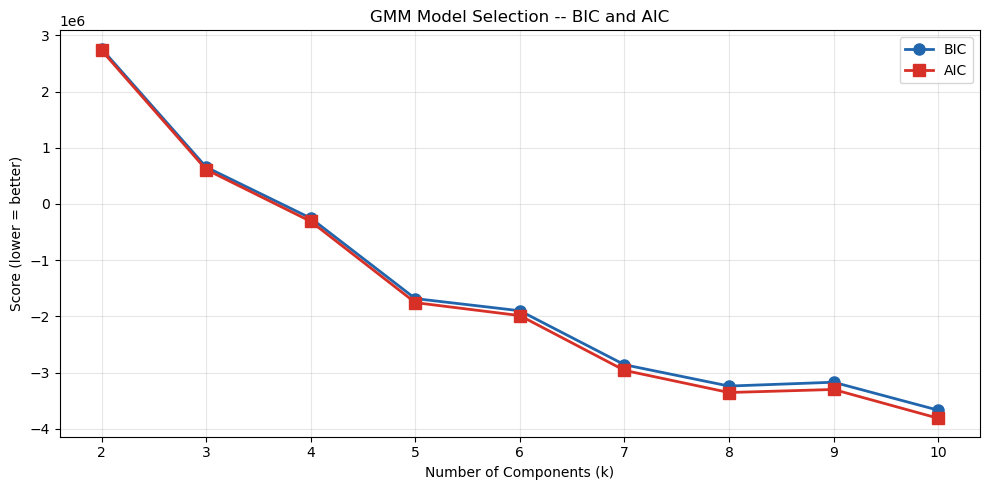

In [26]:
# GMM with same k values
bic_scores = []
aic_scores = []
k_range_gmm = range(2, 11)

for k in k_range_gmm:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    print(f"  k={k}  BIC={gmm.bic(X_scaled):>14,.0f}  AIC={gmm.aic(X_scaled):>14,.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range_gmm, bic_scores, marker='o', linewidth=2, 
        markersize=8, label='BIC', color='#2166ac')
ax.plot(k_range_gmm, aic_scores, marker='s', linewidth=2, 
        markersize=8, label='AIC', color='#d73027')
ax.set_title('GMM Model Selection -- BIC and AIC')
ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('Score (lower = better)')
ax.set_xticks(k_range_gmm)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('../figs/clustering/gmm_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparing K-Means vs GMM for k = 4

In [27]:
# Run GMM with k=4
gmm_final = GaussianMixture(n_components=4, random_state=42, n_init=5)
gmm_labels = gmm_final.fit_predict(X_scaled)

# Also run K-Means with k=4 for comparison
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels_4 = kmeans_4.fit_predict(X_scaled)

# Compare silhouette scores
from sklearn.metrics import silhouette_score

sil_gmm = silhouette_score(X_scaled, gmm_labels, sample_size=10000, random_state=42)
sil_km4 = silhouette_score(X_scaled, kmeans_labels_4, sample_size=10000, random_state=42)

print(f"Silhouette -- GMM k=4:     {sil_gmm:.4f}")
print(f"Silhouette -- K-Means k=4: {sil_km4:.4f}")

# Distribution comparison
print(f"\nGMM k=4 distribution:")
import pandas as pd
print(pd.Series(gmm_labels).value_counts().sort_index())

print(f"\nK-Means k=4 distribution:")
print(pd.Series(kmeans_labels_4).value_counts().sort_index())

Silhouette -- GMM k=4:     0.0588
Silhouette -- K-Means k=4: 0.1096

GMM k=4 distribution:
0     1504
1    14074
2    30196
3    12903
Name: count, dtype: int64

K-Means k=4 distribution:
0    33453
1     1396
2     9970
3    13858
Name: count, dtype: int64


In [28]:
# Final model -- K-Means k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Final cluster distribution:")
dist = df_model['cluster'].value_counts().sort_index()
for cluster, count in dist.items():
    pct = count / len(df_model) * 100
    print(f"  Cluster {cluster}: {count:>6,} customers ({pct:.1f}%)")

# Profile
profile = df_model.groupby('cluster').agg(
    customer_count       = ('customer_id', 'count'),
    avg_total_spend      = ('total_spend_log', 'mean'),
    avg_txn_count        = ('transaction_count_log', 'mean'),
    avg_grocery          = ('grocery_share', 'mean'),
    avg_dining           = ('dining_share', 'mean'),
    avg_gas              = ('gas_share', 'mean'),
    avg_digital          = ('digital_share', 'mean'),
    avg_retail           = ('retail_share', 'mean'),
    avg_age              = ('Age', 'mean'),
    avg_relationship_yrs = ('RelationshipYears', 'mean'),
    avg_weekend_share    = ('weekend_share', 'mean'),
    avg_unique_merchants = ('unique_merchants_log', 'mean'),
    pct_primary          = ('is_primary', 'mean'),
    pct_wealth           = ('is_wealth', 'mean'),
).round(3)

print()
print(profile.T.to_string())

Final cluster distribution:
  Cluster 0: 33,453 customers (57.0%)
  Cluster 1:  1,396 customers (2.4%)
  Cluster 2:  9,970 customers (17.0%)
  Cluster 3: 13,858 customers (23.6%)

cluster                    0       1       2       3
customer_count         33453    1396    9970   13858
avg_total_spend        8.047   7.225   4.484   7.266
avg_txn_count          4.403   3.488   1.626   2.751
avg_grocery            0.225   0.202   0.142   0.166
avg_dining             0.116    0.09   0.106   0.037
avg_gas                0.097   0.082   0.088   0.034
avg_digital            0.028   0.035     0.1   0.012
avg_retail             0.133   0.115   0.093   0.092
avg_age               48.536  51.161  48.913  50.361
avg_relationship_yrs  13.734  14.554  14.357   14.73
avg_weekend_share      0.286   0.268   0.272    0.24
avg_unique_merchants   3.646   2.896   1.347   2.323
pct_primary            0.671    0.92   0.663   0.671
pct_wealth             0.007   0.023   0.007   0.008


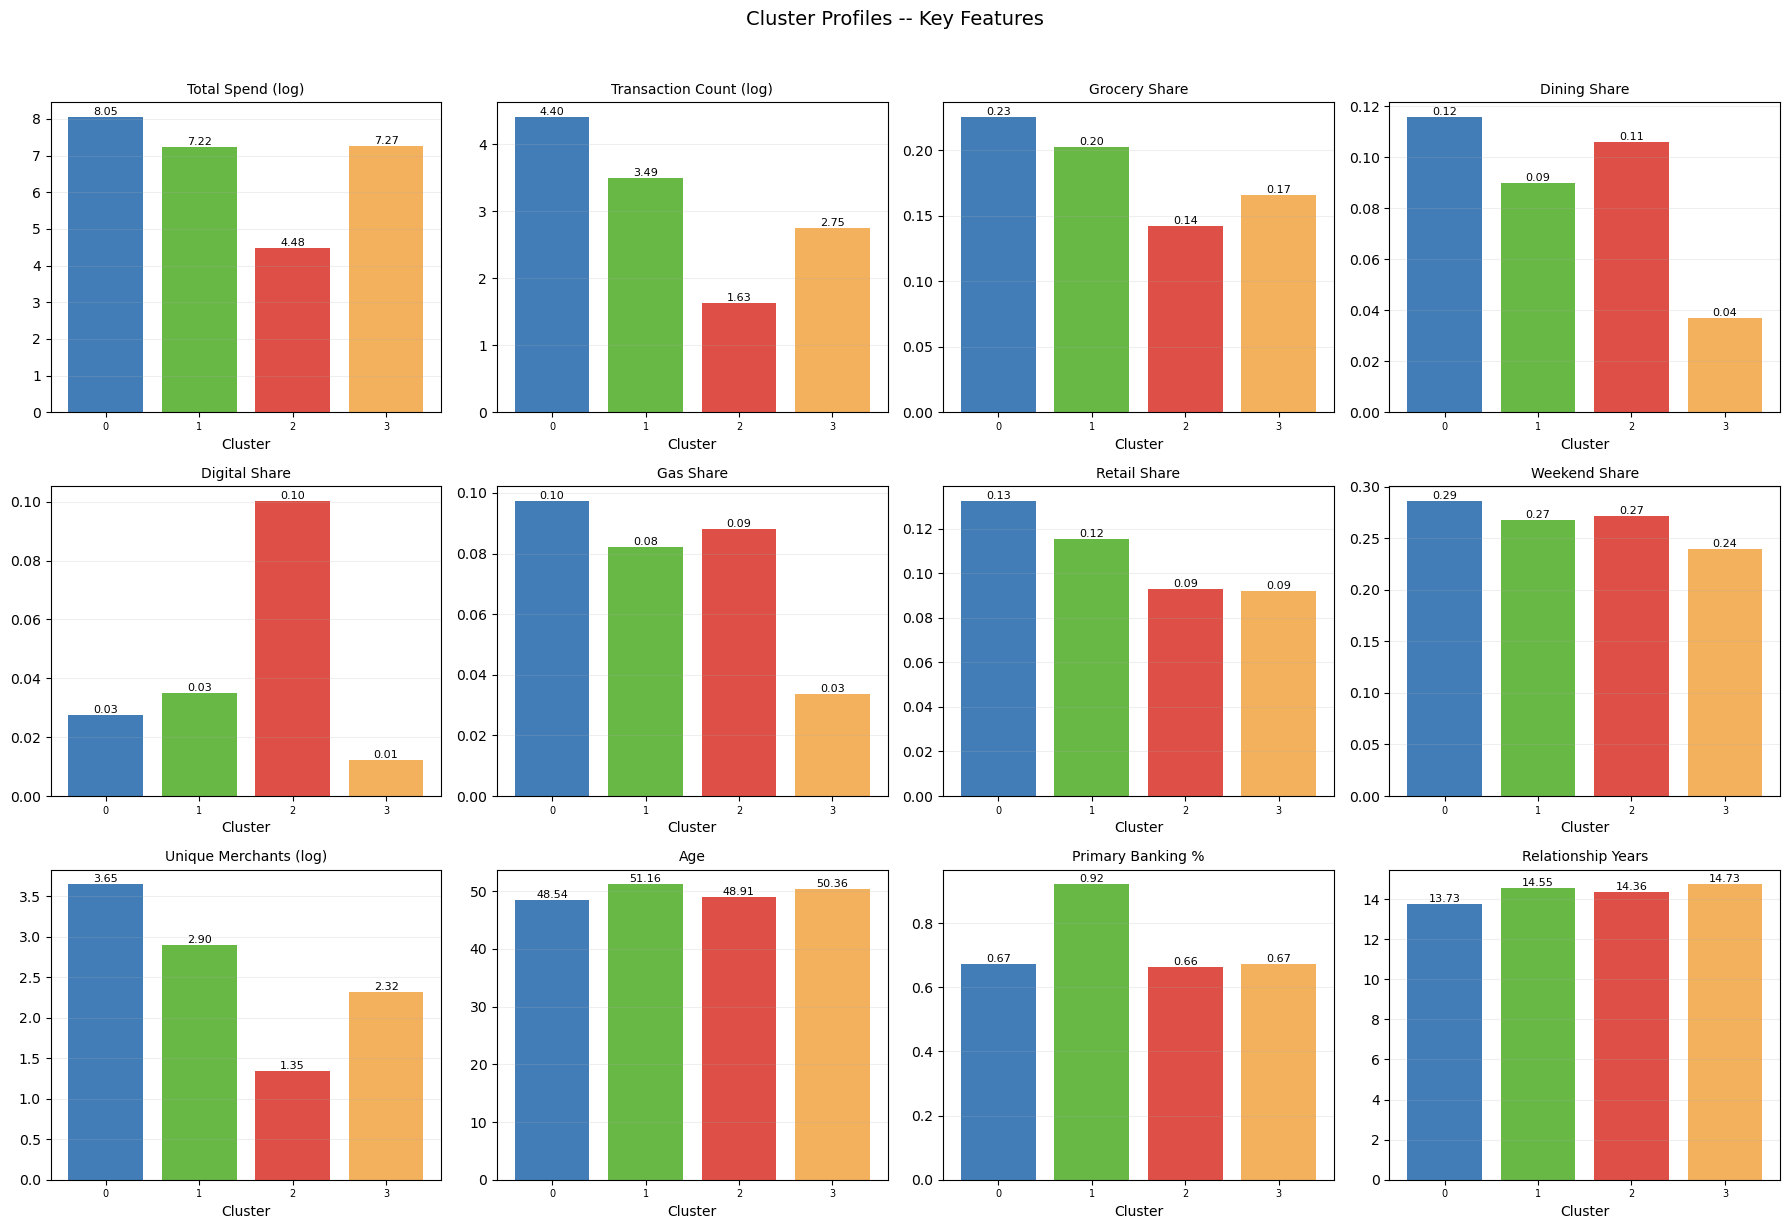

In [34]:
plot_features = {
    'Total Spend (log)':       'total_spend_log',
    'Transaction Count (log)': 'transaction_count_log',
    'Grocery Share':           'grocery_share',
    'Dining Share':            'dining_share',
    'Digital Share':           'digital_share',
    'Gas Share':               'gas_share',
    'Retail Share':            'retail_share',
    'Weekend Share':           'weekend_share',
    'Unique Merchants (log)':  'unique_merchants_log',
    'Age':                     'Age',
    'Primary Banking %':       'is_primary',
    'Relationship Years':      'RelationshipYears',
}

cluster_means = df_model.groupby('cluster')[list(plot_features.values())].mean()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
colors = ['#2166ac', '#4dac26', '#d73027', '#f1a340']  # 4 colors for 4 clusters

for idx, (label, col) in enumerate(plot_features.items()):
    ax = axes[idx]
    values = cluster_means[col]
    bars = ax.bar(range(4), values, color=colors, alpha=0.85)  # range(4)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_xticks(range(4))
    ax.set_xticklabels([
        '0',
        '1',
        '2',
        '3'
    ], fontsize=7)
    ax.bar_label(bars, fmt='%.2f', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Cluster Profiles -- Key Features', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('../figs/clustering/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Compare each cluster to the population mean
# Positive = above average, Negative = below average

pop_mean = df_model[list(plot_features.values())].mean()

print("Deviation from population mean (cluster mean - population mean):")
print("Positive = above average, Negative = below average")
print()

deviation = cluster_means.subtract(pop_mean, axis=1).round(3)
print(deviation.T.to_string())

Deviation from population mean (cluster mean - population mean):
Positive = above average, Negative = below average

cluster                    0      1      2      3
total_spend_log        0.809 -0.013 -2.753  0.029
transaction_count_log  0.884 -0.032 -1.894 -0.768
grocery_share          0.029  0.006 -0.054 -0.031
dining_share           0.021 -0.005  0.011 -0.058
digital_share         -0.009 -0.002  0.064 -0.024
gas_share              0.017  0.002  0.008 -0.047
retail_share           0.017   -0.0 -0.023 -0.024
weekend_share          0.014 -0.004 -0.001 -0.033
unique_merchants_log   0.721 -0.029 -1.578 -0.603
Age                   -0.558  2.067 -0.181  1.268
is_primary            -0.005  0.245 -0.012 -0.004
RelationshipYears     -0.361  0.459  0.263  0.635


In [31]:
# Full deviation table -- all 55 features
all_features = [col for col in df_model.columns 
                if col not in identifier_cols + ['cluster', 'cluster_name']]

full_deviation = df_model.groupby('cluster')[all_features].mean().subtract(
    df_model[all_features].mean(), axis=1
).round(3)

print("Top 5 most distinctive features per cluster:")
for cluster in range(4):
    top = full_deviation.loc[cluster].abs().sort_values(ascending=False).head(5)
    print(f"\nCluster {cluster}:")
    for feat, val in top.items():
        direction = "+" if full_deviation.loc[cluster, feat] > 0 else "-"
        print(f"  {direction}{abs(val):.3f}  {feat}")

Top 5 most distinctive features per cluster:

Cluster 0:
  +3.632  avg_transactions_per_week
  +0.884  transaction_count_log
  +0.809  total_spend_log
  +0.721  unique_merchants_log
  -0.558  Age

Cluster 1:
  +2.067  Age
  +0.985  NumberCreditCardAccts
  +0.976  has_creditcard
  +0.648  NumberActiveDDAs
  +0.459  RelationshipYears

Cluster 2:
  -6.052  avg_transactions_per_week
  -2.753  total_spend_log
  -1.919  std_transaction_amount_log
  -1.894  transaction_count_log
  -1.743  max_transaction_amount_log

Cluster 3:
  -4.397  avg_transactions_per_week
  +1.268  Age
  +0.876  std_transaction_amount_log
  +0.800  avg_transaction_amount_log
  -0.768  transaction_count_log


In [32]:
# Cluster names -- based on deviation analysis
cluster_names = {
    0: 'High Engagement Spenders',
    1: 'Multi-Product Loyal Customers',
    2: 'Disengaged Customers',
    3: 'Infrequent High-Value Buyers'
}

df_model['cluster_name'] = df_model['cluster'].map(cluster_names)

print('Final segments:')
summary = df_model.groupby(['cluster', 'cluster_name']).size().reset_index(name='count')
summary['pct'] = (summary['count'] / len(df_model) * 100).round(1)
print(summary.to_string(index=False))

Final segments:
 cluster                  cluster_name  count  pct
       0      High Engagement Spenders  33453 57.0
       1 Multi-Product Loyal Customers   1396  2.4
       2          Disengaged Customers   9970 17.0
       3  Infrequent High-Value Buyers  13858 23.6
